# 07 — SHAP Explainability & Reason Codes
**TrustGraph Credit Risk Project**

Runs SHAP on the production LightGBM model, generates summary plots, waterfall plots
for individual borrowers, and plain-English reason codes for the 3 India profiles.

In [1]:
import os, sys, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from pathlib import Path

from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
shap.initjs()
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

ROOT       = Path(os.getcwd()).parent if Path(os.getcwd()).name == 'notebooks' else Path(os.getcwd())
DATA_PROC  = ROOT / 'data' / 'processed'
CHARTS_DIR = DATA_PROC / 'eda_charts'
MODELS_DIR = ROOT / 'models'
SRC_DIR    = ROOT / 'src'
sys.path.insert(0, str(SRC_DIR))

from explainability import reason_code_generator, batch_reason_codes

lgbm_path = MODELS_DIR / 'lgbm_final.pkl'
if not lgbm_path.exists():
    raise FileNotFoundError(f"{lgbm_path} — run 04_gbm.ipynb first.")
print("Imports OK")

Imports OK


## 1. Load model and feature matrix

In [2]:
with open(lgbm_path, 'rb') as f:
    model = pickle.load(f)

df = pd.read_csv(DATA_PROC / 'features_train.csv')
y  = df['TARGET']
X  = df.drop(columns=['TARGET', 'SK_ID_CURR'], errors='ignore')

_, X_val, _, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"Validation set: {X_val.shape}")

Validation set: (61503, 128)


## 2. Compute SHAP values on validation set

In [3]:
# Use a 2000-sample subset for speed; full val set is ~61k rows
SHAP_SAMPLE = 2000
idx_sample  = np.random.default_rng(42).choice(len(X_val), SHAP_SAMPLE, replace=False)
X_shap      = X_val.iloc[idx_sample].reset_index(drop=True)
y_shap      = y_val.iloc[idx_sample].reset_index(drop=True)

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)   # shape: (n_samples, n_features) for class-1

# TreeExplainer returns list [class0, class1] for binary classifiers
if isinstance(shap_values, list):
    sv = shap_values[1]   # class-1 (default) SHAP values
else:
    sv = shap_values

print(f"SHAP values shape: {sv.shape}")

SHAP values shape: (2000, 128)


## 3. SHAP Summary Plot (beeswarm)

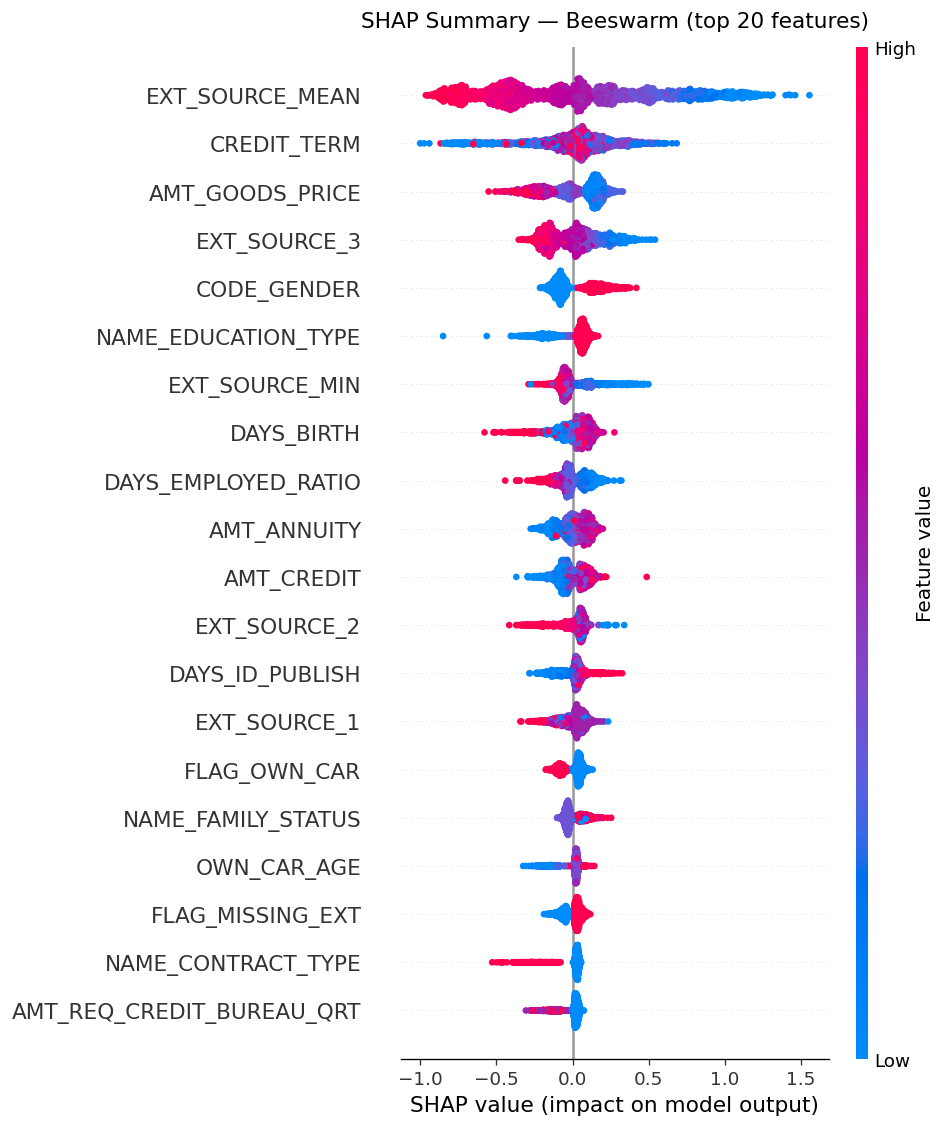

Saved: C:\Users\krish\Downloads\TrustGraph\data\processed\eda_charts\shap_beeswarm.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 9))
shap.summary_plot(sv, X_shap, plot_type='dot', max_display=20, show=False)
plt.title('SHAP Summary — Beeswarm (top 20 features)', fontsize=13, pad=12)
plt.tight_layout()
beeswarm_path = CHARTS_DIR / 'shap_beeswarm.png'
plt.savefig(beeswarm_path, bbox_inches='tight')
plt.show()
print(f"Saved: {beeswarm_path}")

## 4. SHAP Bar Chart (mean |SHAP|)

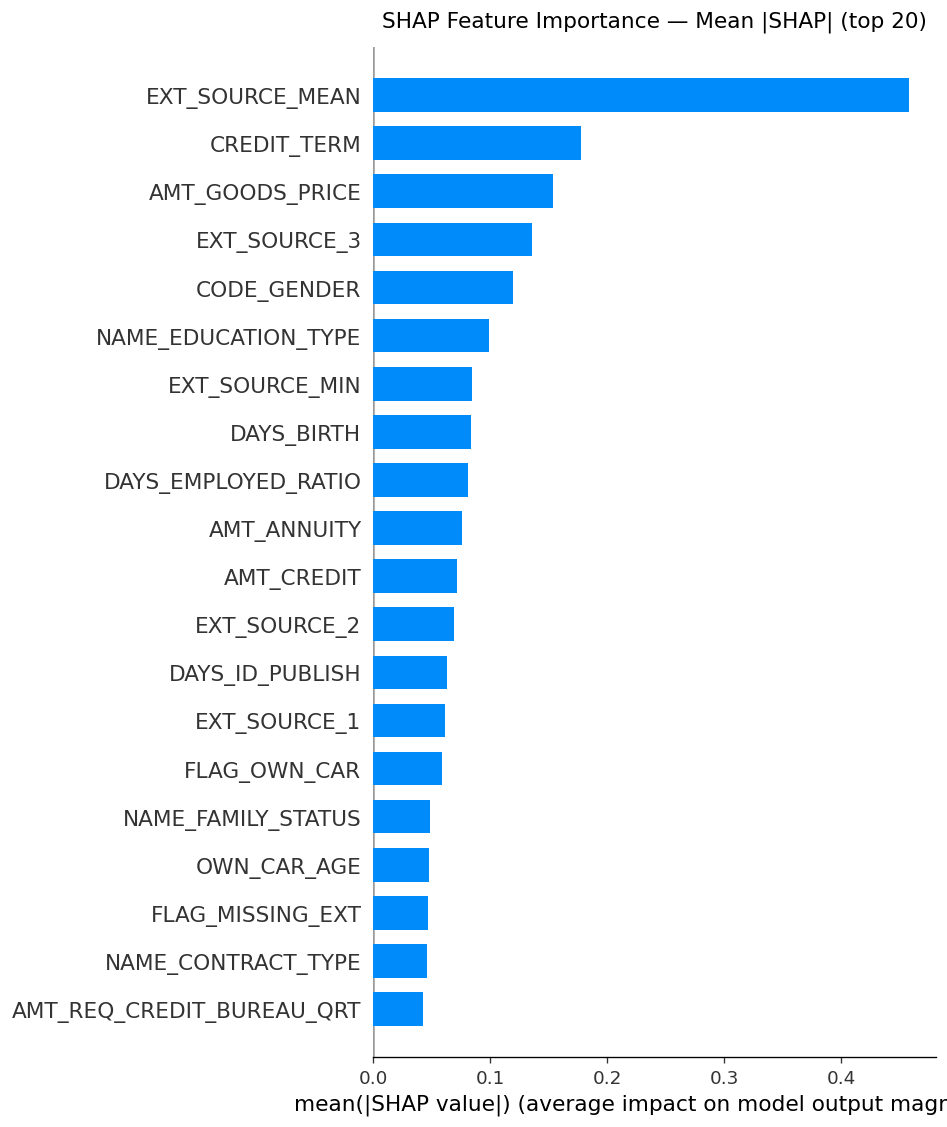

Saved: C:\Users\krish\Downloads\TrustGraph\data\processed\eda_charts\shap_bar.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(sv, X_shap, plot_type='bar', max_display=20, show=False)
plt.title('SHAP Feature Importance — Mean |SHAP| (top 20)', fontsize=13, pad=12)
plt.tight_layout()
bar_path = CHARTS_DIR / 'shap_bar.png'
plt.savefig(bar_path, bbox_inches='tight')
plt.show()
print(f"Saved: {bar_path}")

## 5. Waterfall plots — 3 individual borrowers
One defaulter, one non-defaulter, one borderline case.

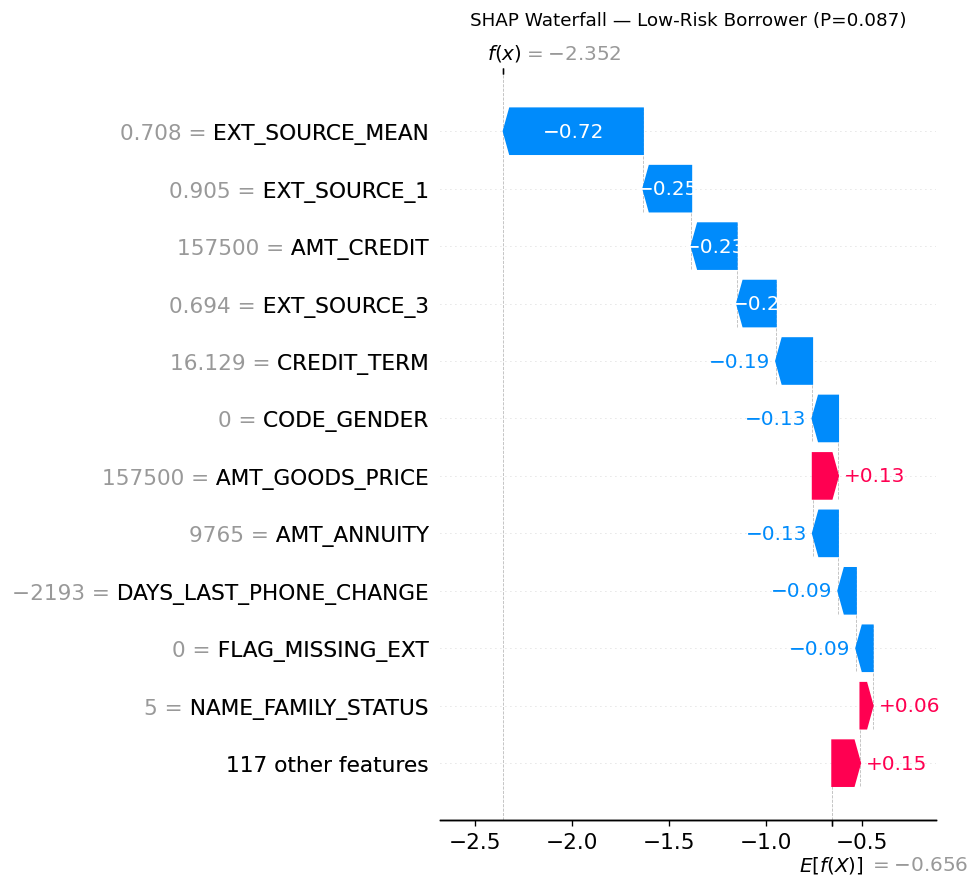

Saved: C:\Users\krish\Downloads\TrustGraph\data\processed\eda_charts\shap_waterfall_approved.png


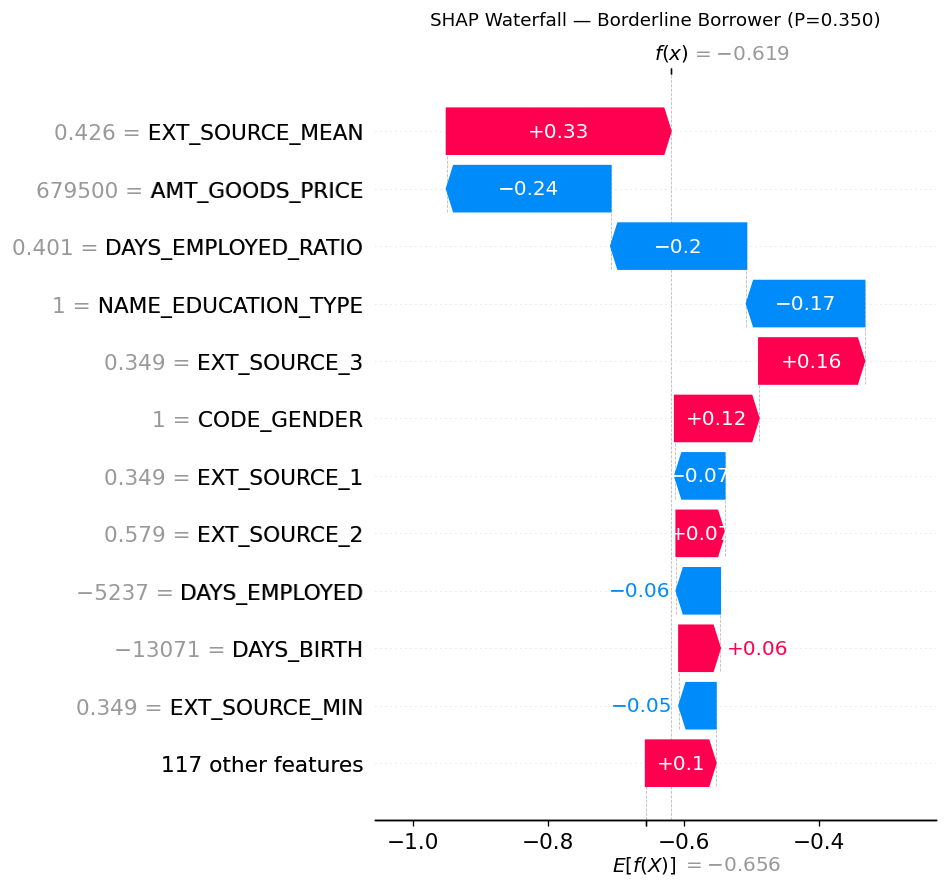

Saved: C:\Users\krish\Downloads\TrustGraph\data\processed\eda_charts\shap_waterfall_borderline.png


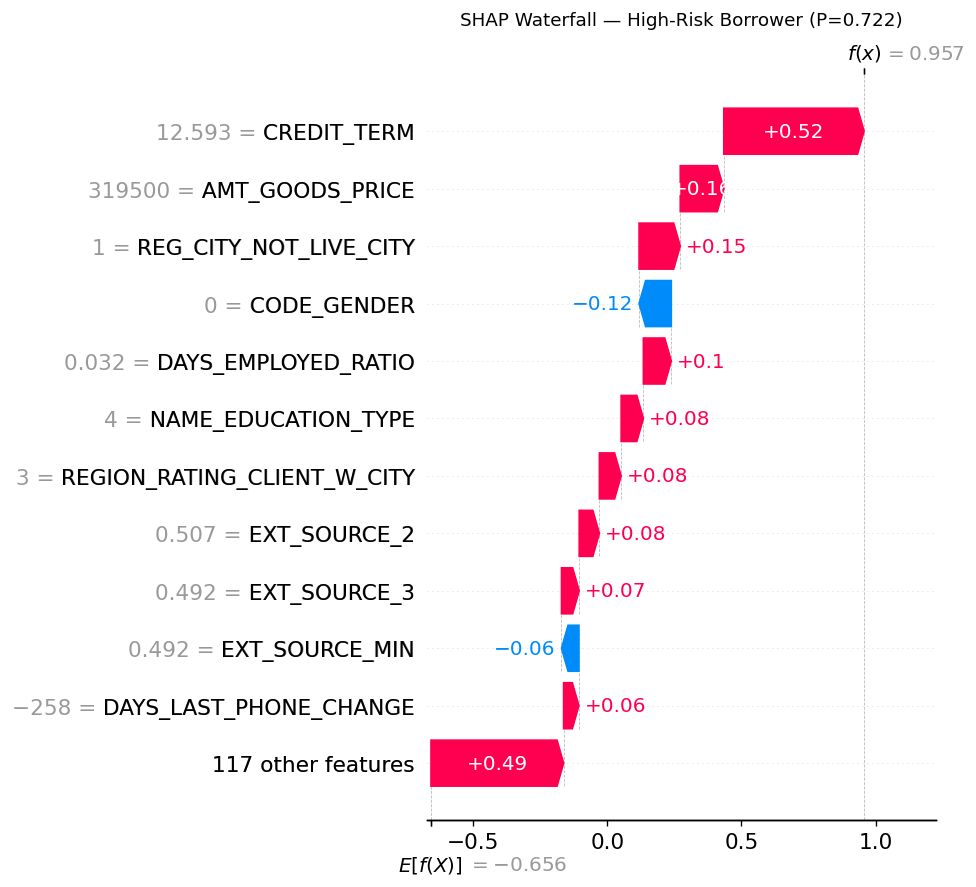

Saved: C:\Users\krish\Downloads\TrustGraph\data\processed\eda_charts\shap_waterfall_declined.png


In [6]:
prob_shap = model.predict_proba(X_shap)[:, 1]

# Pick representative borrowers
idx_approve  = int(np.where(prob_shap < 0.15)[0][0])
idx_borderline = int(np.argmin(np.abs(prob_shap - 0.35)))
idx_decline  = int(np.where(prob_shap > 0.65)[0][0])

showcase = [
    (idx_approve,    f'Low-Risk Borrower (P={prob_shap[idx_approve]:.3f})',    'approved'),
    (idx_borderline, f'Borderline Borrower (P={prob_shap[idx_borderline]:.3f})', 'borderline'),
    (idx_decline,    f'High-Risk Borrower (P={prob_shap[idx_decline]:.3f})',   'declined'),
]

shap_exp = explainer(X_shap)   # Explanation object for waterfall
if hasattr(shap_exp, 'values') and isinstance(shap_exp.values, list):
    # binary: pick class-1
    import copy
    shap_exp_c1 = copy.copy(shap_exp)
    shap_exp_c1.values   = shap_exp.values[:, :, 1]
    shap_exp_c1.base_values = shap_exp.base_values[:, 1]
else:
    shap_exp_c1 = shap_exp

for idx, title, fname in showcase:
    fig, ax = plt.subplots(figsize=(11, 6))
    shap.waterfall_plot(shap_exp_c1[idx], max_display=12, show=False)
    plt.title(f'SHAP Waterfall — {title}', fontsize=11, pad=10)
    plt.tight_layout()
    wf_path = CHARTS_DIR / f'shap_waterfall_{fname}.png'
    plt.savefig(wf_path, bbox_inches='tight')
    plt.show()
    print(f"Saved: {wf_path}")

## 6. Reason code generator — India profiles

> **SYNTHETIC** — India profiles from notebook 06 are simulated. Reason codes below are illustrative.

In [7]:
from india_layer import map_to_trustgraph_schema, generate_transactions, make_decision

india_path = DATA_PROC / 'india_profiles.csv'
india_df   = pd.read_csv(india_path)
india_df   = india_df.set_index('borrower_type')

feature_names = list(X_shap.columns)

india_records = []
for btype in india_df.index:
    row = india_df.loc[btype]
    # Build feature vector
    x_row = pd.DataFrame([{f: row.get(f, 0) for f in feature_names}])
    prob  = float(model.predict_proba(x_row)[0, 1])
    sv_i  = explainer.shap_values(x_row)
    sv_i  = sv_i[1][0] if isinstance(sv_i, list) else sv_i[0]

    code  = reason_code_generator(sv_i, feature_names, prob)
    india_records.append({
        'borrower_type':   btype,
        'default_prob':    round(prob, 4),
        'decision':        make_decision(prob),
        'reason_code':     code,
        'data_is_synthetic': True,
    })

rc_df = pd.DataFrame(india_records)
rc_df

,borrower_type,default_prob,decision,reason_code,data_is_synthetic
0,Kirana Shop Owner,0.6571,Decline,"Declined — weak external credit scores, at lea...",True
1,Gig Worker (Swiggy/Ola),0.5617,Decline,"Declined — weak external credit scores, weak t...",True
2,Small Farmer,0.4906,Refer,Refer for manual review — borderline risk prof...,True


In [8]:
rc_path = DATA_PROC / 'reason_codes.csv'
rc_df.to_csv(rc_path, index=False)
print(f"Saved: {rc_path}")
print()
print("=" * 68)
print("  REASON CODES — INDIA PROFILES  [ALL DATA SYNTHETIC]")
print("=" * 68)
for _, r in rc_df.iterrows():
    print(f"\n  {r['borrower_type']}")
    print(f"  P(default)={r['default_prob']:.4f}  |  Decision: {r['decision']}")
    print(f"  {r['reason_code']}")
print("\n" + "=" * 68)

Saved: C:\Users\krish\Downloads\TrustGraph\data\processed\reason_codes.csv

  REASON CODES — INDIA PROFILES  [ALL DATA SYNTHETIC]

  Kirana Shop Owner
  P(default)=0.6571  |  Decision: Decline
  Declined — weak external credit scores, at least one very low bureau score. Mitigating factor: positive applicant profile, but insufficient to offset risk profile. Predicted default probability: 65.7%.

  Gig Worker (Swiggy/Ola)
  P(default)=0.5617  |  Decision: Decline
  Declined — weak external credit scores, weak tertiary bureau score. Mitigating factor: positive applicant profile, but insufficient to offset risk profile. Predicted default probability: 56.2%.

  Small Farmer
  P(default)=0.4906  |  Decision: Refer
  Refer for manual review — borderline risk profile. Strengths: positive applicant profile. Concerns: weak external credit scores, weak tertiary bureau score. Predicted default probability: 49.1% — recommend additional income verification.

